# Experiment 1 - W-estimate skill summary

Five presentation figures built from `data/metrics.csv` and the per-cell arrays saved by `run_experiment.py`. Every metric is a plain descriptive statistic (RMS, RMS normalized by the signal std, correlation, bias) - no thresholds or 'best config' judgements are baked in; those are left to discuss.

Run in place after `run_experiment.py` has populated `data/`.

In [1]:
import os, sys
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

REPO = "/home/edavenport/analysis/tpose24-osse"
HERE = os.path.join(REPO, "experiment_1")
sys.path.insert(0, REPO)
import osse_tools as ot

DATA   = os.path.join(HERE, "data")
SUMDIR = os.path.join(HERE, "summary_figs"); os.makedirs(SUMDIR, exist_ok=True)
plt.rcParams["figure.dpi"] = 120

m = pd.read_csv(os.path.join(DATA, "metrics.csv"))
FAM_COLORS = {"shift": "C0", "equator": "C1", "density": "C2"}

def load_cell(row):
    """Open the saved w_est/w_model/bias arrays for one metrics row."""
    return xr.open_dataset(os.path.join(HERE, row.nc_path))

print(f"{len(m)} config cells across {m.config.nunique()} configs")
m.head()

84 config cells across 48 configs


,config,family,pattern,width,center_lat,n_gliders_cell,n_gliders_total,cell_height_deg,min_depth,max_depth,nc_path,rms,mean_bias,corr,w_est_std,w_model_std,norm_rms,n
0,density_2g_w0.25,density,density_2g,0.25,0.5,2,2,1.0,8,70,data/density_2g_w0.25__cell_+0.50.nc,0.000027,-3.785868e-06,0.916948,0.000053,0.000065,0.413177,20736
1,density_2g_w0.5,density,density_2g,0.50,0.5,2,2,1.0,8,70,data/density_2g_w0.5__cell_+0.50.nc,0.000024,-3.773345e-06,0.936226,0.000047,0.000060,0.391665,20736
2,density_2g_w0.75,density,density_2g,0.75,0.5,2,2,1.0,8,70,data/density_2g_w0.75__cell_+0.50.nc,0.000023,-1.613573e-06,0.926771,0.000044,0.000056,0.401607,20736
3,density_2g_w1.0,density,density_2g,1.00,0.5,2,2,1.0,8,70,data/density_2g_w1.0__cell_+0.50.nc,0.000025,-8.383245e-07,0.892178,0.000043,0.000053,0.462170,20736
4,density_2g_w1.5,density,density_2g,1.50,0.5,2,2,1.0,8,70,data/density_2g_w1.5__cell_+0.50.nc,0.000027,2.477612e-07,0.839144,0.000042,0.000050,0.544032,20736


## Figure 1 - skill by array family (how good, and does design matter?)

Skill distribution of every config cell, split by array family and coloured by
array width. The dashed line at `RMS/sigma = 1` is the no-skill reference (an
estimate of zero). Replaces the earlier error-vs-signal / error-vs-correlation
overview: that pair was uninformative because every config beats the trivial
`RMS = signal` line, and normalized error and correlation are two views of the
same quantity so plotting them against each other only shows they agree.

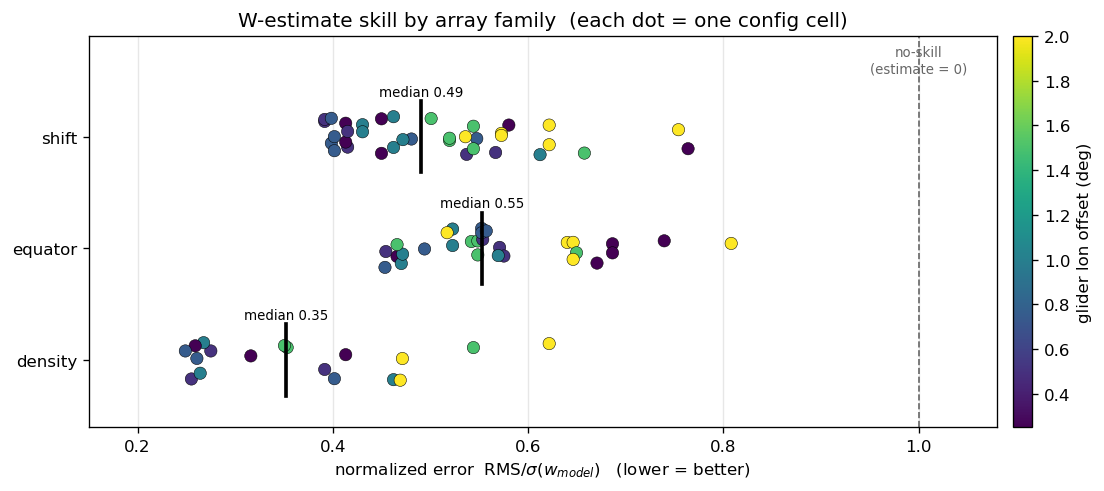

In [2]:
# Figure 1 - skill distribution by array family (each dot = one config cell).
# x = normalized error RMS/sigma (lower is better); dots coloured by array width
# so the within-family spread is explained; black bar = family median;
# dashed line = no-skill reference (estimate = 0 => RMS/sigma = 1).
fams = ["density", "equator", "shift"]          # best -> worst, top -> bottom
ypos = {f: i for i, f in enumerate(fams)}
rng = np.random.default_rng(0)

fig, ax = plt.subplots(figsize=(10, 4.2))
sc = None
for f in fams:
    s = m[m.family == f]
    jit = rng.uniform(-0.18, 0.18, len(s))
    sc = ax.scatter(s.norm_rms, ypos[f] + jit, c=s.width, cmap="viridis",
                    vmin=m.width.min(), vmax=m.width.max(),
                    s=55, edgecolor="k", lw=0.3, zorder=3)
    med = s.norm_rms.median()
    ax.plot([med, med], [ypos[f] - 0.32, ypos[f] + 0.32], "k-", lw=2.2, zorder=4)
    ax.text(med, ypos[f] + 0.34, f"median {med:.2f}", ha="center", va="bottom",
            fontsize=8)

ax.axvline(1.0, color="0.4", ls="--", lw=1)
ax.text(1.0, len(fams) - 0.45, "no-skill\n(estimate = 0)", color="0.4",
        fontsize=8, ha="center", va="bottom")

ax.set_yticks(range(len(fams)))
ax.set_yticklabels(fams)
ax.set_ylim(-0.6, len(fams) - 0.1)
ax.set_xlim(0.15, 1.08)
ax.set_xlabel(r"normalized error  RMS/$\sigma(w_{model})$   (lower = better)")
ax.set_title("W-estimate skill by array family  (each dot = one config cell)")
ax.grid(axis="x", alpha=0.3)
cb = fig.colorbar(sc, ax=ax, pad=0.015)
cb.set_label("glider lon offset (deg)")
fig.tight_layout()
fig.savefig(os.path.join(SUMDIR, "fig1_skill_overview.png"), dpi=150, bbox_inches="tight")
plt.show()

## Figure 2 - skill vs array width

One line per (method, estimate location). **Colour = where the estimate is
centred** (`center_lat`), so estimates at the same latitude share a colour;
**linestyle + marker = method** (the sampling pattern). This disaggregates the
multi-cell arrays, which the earlier one-line-per-pattern version hid by
averaging over cells at different latitudes.

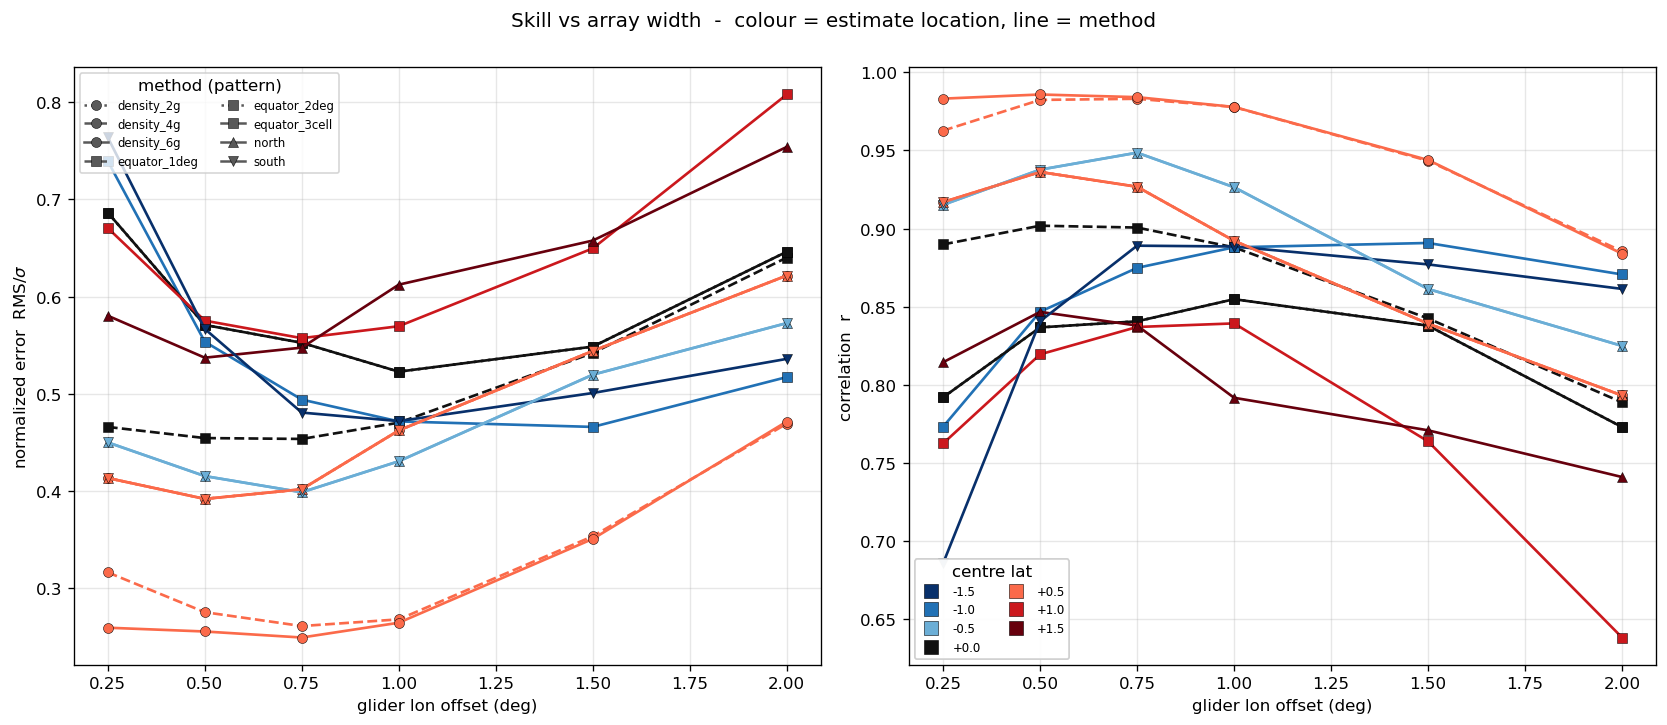

In [3]:
# Figure 2 - skill vs array width, one line per (method, estimate location).
# COLOUR = centre latitude (where the estimate sits): blues south, black
# equator, reds north -> same-location estimates share a colour.
# LINESTYLE + MARKER = method (pattern): marker groups the array family
# (o density, s equator, ^/v shifted N/S), linestyle the sub-variant.
LAT_COLORS = {
    -1.5: "#08306b", -1.0: "#2171b5", -0.5: "#6baed6",
     0.0: "#111111",
     0.5: "#fb6a4a",  1.0: "#cb181d",  1.5: "#67000d",
}
PAT_STYLE = {
    "density_2g":    (":",  "o"), "density_4g":    ("--", "o"),
    "density_6g":    ("-",  "o"),
    "equator_1deg":  ("--", "s"), "equator_2deg":  (":",  "s"),
    "equator_3cell": ("-",  "s"),
    "north":         ("-",  "^"), "south":         ("-",  "v"),
}

g = (m.groupby(["family", "pattern", "center_lat", "width"], as_index=False)
       [["norm_rms", "corr"]].mean())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for (pat, lat), d in g.groupby(["pattern", "center_lat"]):
    d = d.sort_values("width")
    ls, mk = PAT_STYLE[pat]
    col = LAT_COLORS[lat]
    axes[0].plot(d.width, d.norm_rms, ls=ls, marker=mk, color=col, lw=1.6,
                 ms=6, mec="k", mew=0.3)
    axes[1].plot(d.width, d["corr"], ls=ls, marker=mk, color=col, lw=1.6,
                 ms=6, mec="k", mew=0.3)
axes[0].set_ylabel(r"normalized error  RMS/$\sigma$")
axes[1].set_ylabel("correlation  r")
for ax in axes:
    ax.set_xlabel("glider lon offset (deg)"); ax.grid(alpha=0.3)

# two legends: colour = estimate location, line = method
from matplotlib.lines import Line2D
lat_handles = [Line2D([0], [0], marker="s", ls="", mfc=LAT_COLORS[l], mec="k",
                      mew=0.3, ms=8, label=f"{l:+.1f}")
               for l in sorted(LAT_COLORS)]
pat_handles = [Line2D([0], [0], color="0.35", ls=PAT_STYLE[p][0],
                      marker=PAT_STYLE[p][1], mfc="0.35", mec="k", mew=0.3,
                      label=p) for p in PAT_STYLE]
leg1 = axes[1].legend(handles=lat_handles, title="centre lat", fontsize=7,
                      loc="lower left", ncol=2)
axes[1].add_artist(leg1)
axes[0].legend(handles=pat_handles, title="method (pattern)", fontsize=7,
               loc="upper left", ncol=2)
fig.suptitle("Skill vs array width  -  colour = estimate location, line = method",
             y=1.0)
fig.tight_layout()
fig.savefig(os.path.join(SUMDIR, "fig2_skill_vs_width.png"), dpi=150, bbox_inches="tight")
plt.show()

## Figures 2a-2d - skill vs width, one pattern at a time

Per-pattern breakdown of the combined Figure 2, so each is readable. x = glider
lon offset throughout; each panel colours its lines by whatever is actually
being swept within that pattern (never by width), and carries a third panel with
the platform layout (squares = moorings, circles = gliders; offset drawn = 0.5°).

- **2a shifted arrays** - north + south combined (their ±0.5° cells are identical),
  4 unique cell latitudes (−1.5, −0.5, +0.5, +1.5); colour = cell centre latitude.
  Layout stacked: the four 1°-tall cells tile lat −2→+2 on the moorings.
- **2b equator 3-cell** - colour = cell centre latitude (−1 / 0 / +1). Layout
  stacked: three 2°-tall cells, overlapping, sharing the −2…+2 moorings.
- **2c density** - centre fixed at +0.5, colour = gliders-per-cell; layout shows
  the 2/4/6-glider alternatives side by side.
- **2d equator single-cell** - centre fixed at 0.0, colour = meridional cell
  height (1° vs 2° tall); layout shows both alternatives side by side. The 2° cell's
  N/S boundary sits on the ±1° moorings; the 1° cell has no mooring at ±0.5° so its
  N/S boundary must come from gliders.

Multi-cell arrays (2a, 2b) are drawn stacked because their cells coexist;
alternative single-cell configs (2c, 2d) are drawn side by side.

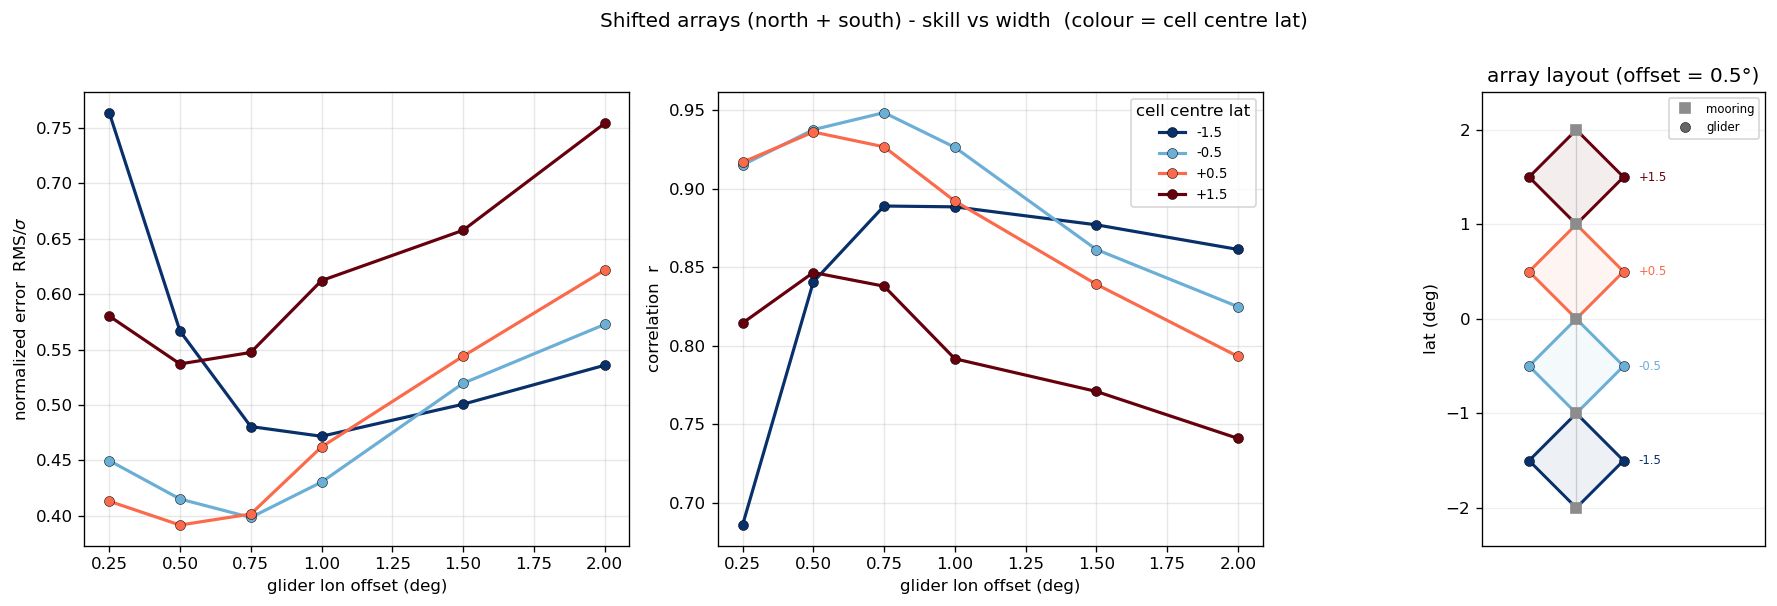

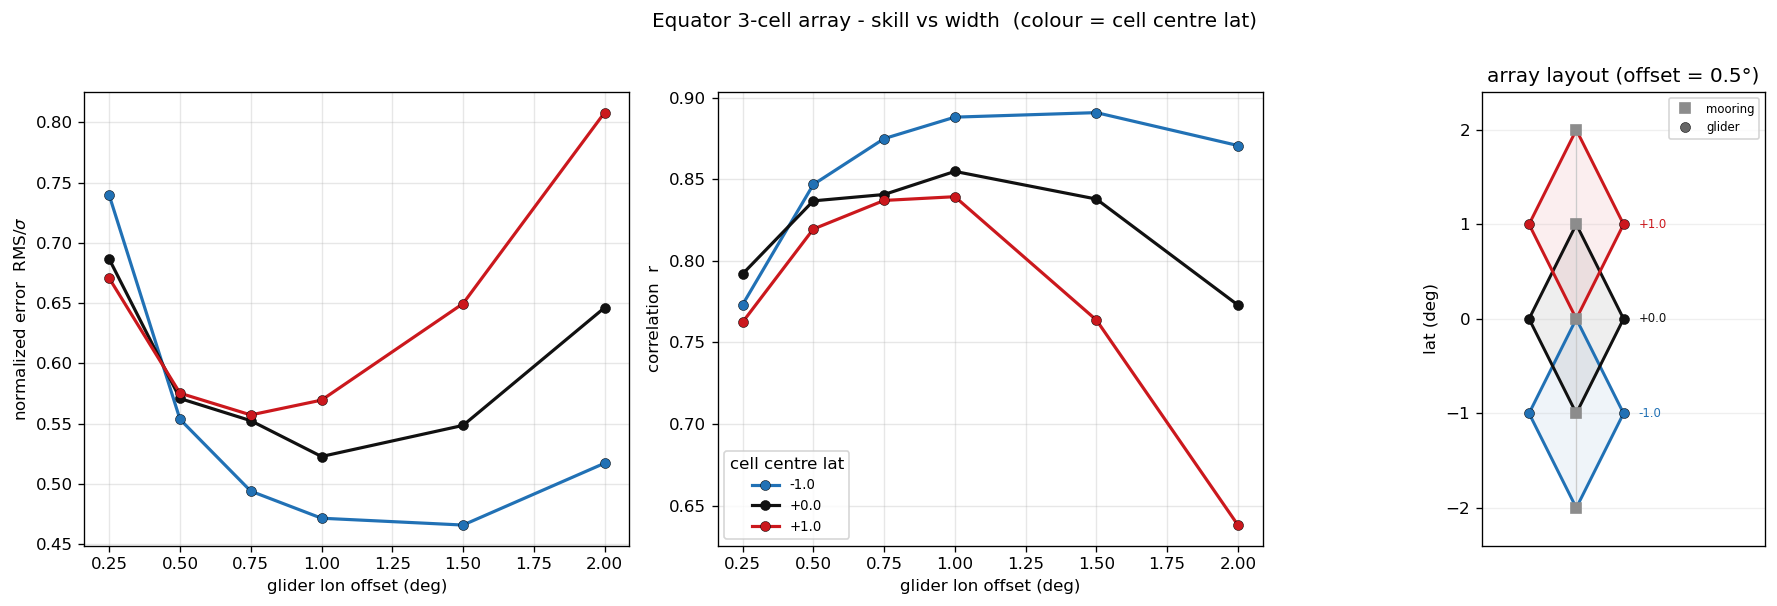

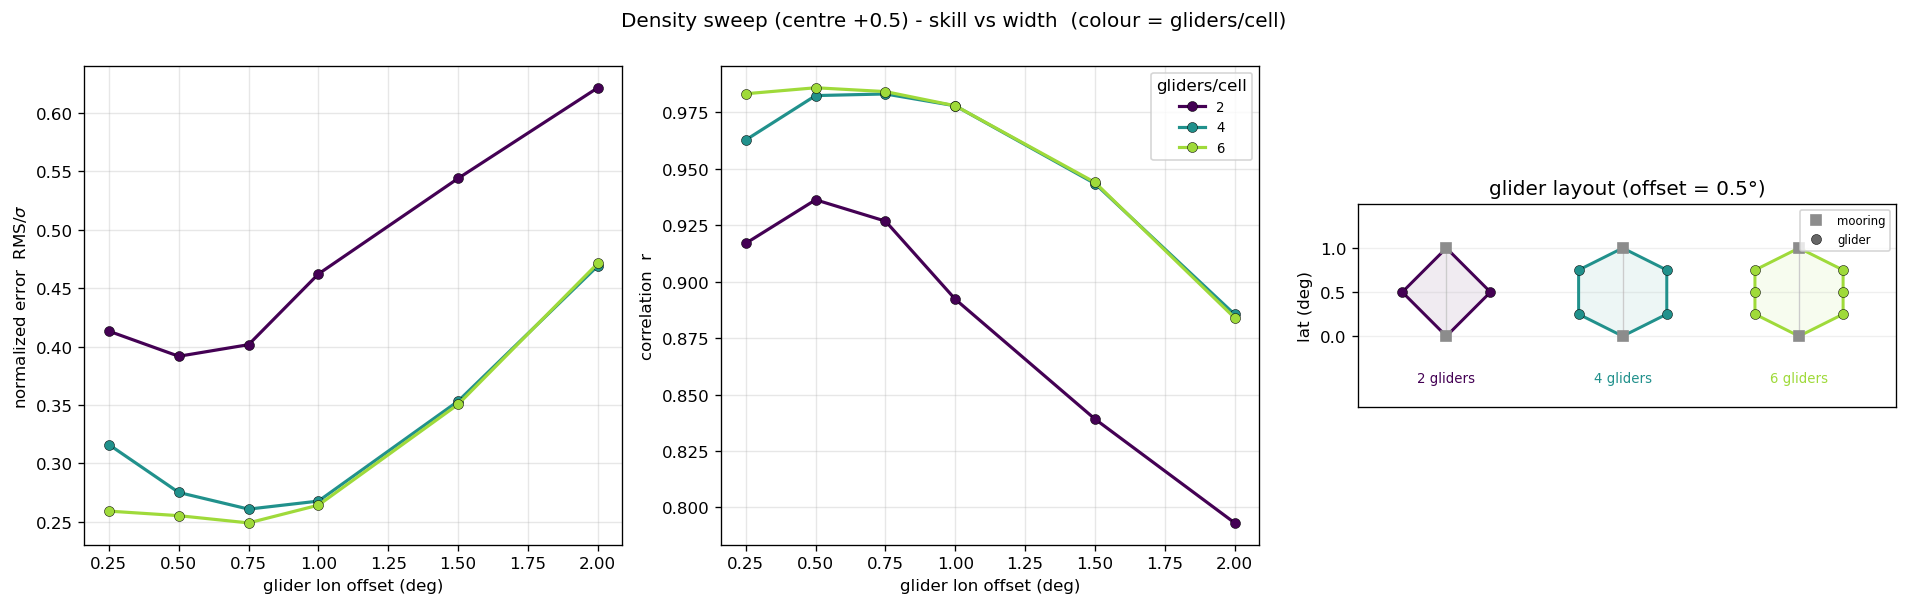

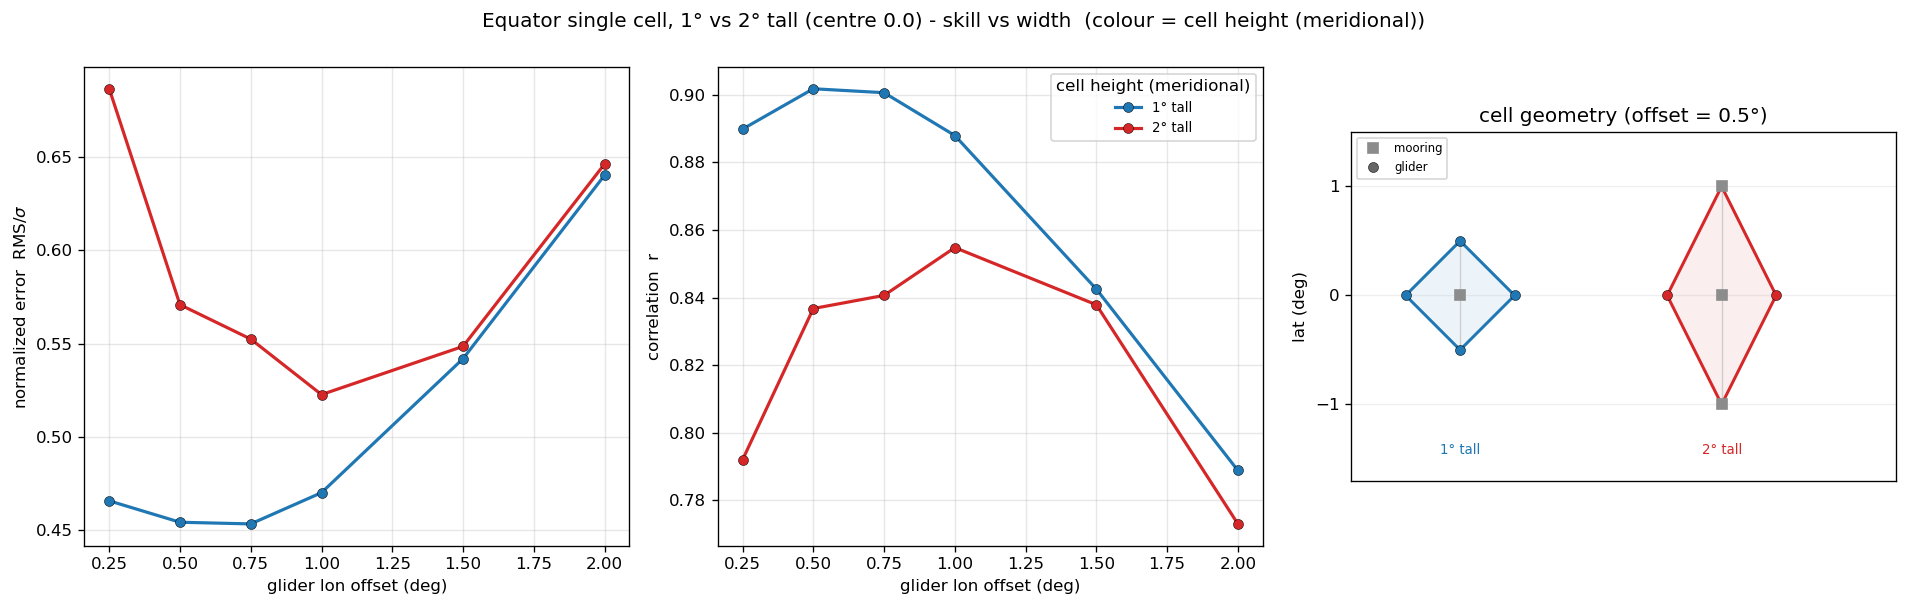

In [4]:
# Figures 2a-2d - skill vs width, one pattern (family) per figure, each with a
# third panel showing the platform layout (offset drawn = 0.5 deg).
# Lines coloured by the parameter actually swept within that pattern (cell centre
# latitude / gliders-per-cell / meridional cell height) - never by width, which
# is already the x-axis. Geometry panels: squares = moorings, circles = gliders,
# hull outline coloured to match the lines. Multi-cell ARRAYS (shift, 3-cell) are
# drawn stacked (the cells coexist); alternative configs (density, 1deg vs 2deg
# equator) are drawn side by side.
GLIDER_COLORS = {2: "#440154", 4: "#21918c", 6: "#9fda3a"}   # sequential
HEIGHT_COLORS = {"equator_1deg": "#1f77b4", "equator_2deg": "#d62728"}
HEIGHT_LBL    = {"equator_1deg": "1° tall", "equator_2deg": "2° tall"}
# LAT_COLORS reused from the combined Figure 2 above (same location -> same colour)

def _lat_lbl(v): return f"{v:+.1f}"

def _hull_poly(pts):
    """Vertices of the convex outline of pts, angle-sorted (pts are convex)."""
    pts = np.array(pts, float)
    c = pts.mean(0)
    order = np.argsort(np.arctan2(pts[:, 1] - c[1], pts[:, 0] - c[0]))
    p = pts[order]
    return np.vstack([p, p[0]])          # closed

def _layout_legend(ax, loc="upper right"):
    ax.plot([], [], marker="s", ls="", color="0.55", ms=6, label="mooring")
    ax.plot([], [], marker="o", ls="", color="0.4", mec="k", mew=0.3, ms=6,
            label="glider")
    ax.legend(fontsize=7, loc=loc)

def _stacked_cells_panel(ax, cells, half, title, off_demo=0.5):
    """Vertical stack of diamond cells (an actual multi-cell array). Each cell is
    2*half deg tall with N/S vertices on the mooring line and E/W gliders at
    +/-off; N/S vertices at integer lat are moorings. Colour = cell centre lat."""
    vlats = sorted({c + s * half for c in cells for s in (-1, 1)})
    moor = [v for v in vlats if abs(v - round(v)) < 1e-9]
    ax.plot([0, 0], [min(vlats), max(vlats)], color="0.8", lw=0.8, zorder=1)
    ax.plot([0] * len(moor), moor, marker="s", ls="", color="0.55", ms=6, zorder=3)
    for c in cells:
        col = LAT_COLORS[c]
        ax.plot([-off_demo, off_demo], [c, c], marker="o", ls="", color=col,
                ms=6, mec="k", mew=0.3, zorder=4)                 # E/W gliders
        poly = _hull_poly([(0, c + half), (off_demo, c), (0, c - half), (-off_demo, c)])
        ax.plot(poly[:, 0], poly[:, 1], "-", color=col, lw=1.8, zorder=2)
        ax.fill(poly[:, 0], poly[:, 1], color=col, alpha=0.07, zorder=0)
        ax.text(off_demo + 0.16, c, f"{c:+.1f}", va="center", ha="left",
                fontsize=7, color=col)
    _layout_legend(ax, loc="upper right")
    ax.set_aspect("equal"); ax.set_xlim(-1.0, 2.0)
    ax.set_ylim(min(vlats) - 0.4, max(vlats) + 0.4)
    ax.set_xticks([]); ax.set_yticks(moor); ax.set_ylabel("lat (deg)")
    ax.set_title(title); ax.grid(alpha=0.2, axis="y")

def _density_geometry_panel(ax, off_demo=0.5):
    """Layouts of the 2/4/6-glider cells (centre +0.5): N/S moorings at lat 0/1,
    glider rows at +/-off. Hull outline coloured to match the lines."""
    rows_by_ng = {2: [0.5], 4: [0.25, 0.75], 6: [0.25, 0.5, 0.75]}
    for i, ng in enumerate((2, 4, 6)):
        xc, col = i * 2.0, GLIDER_COLORS[ng]
        ax.plot([xc, xc], [0, 1], color="0.8", lw=0.8, zorder=1)      # mooring line
        ax.plot([xc, xc], [0, 1], marker="s", ls="", color="0.55", ms=6, zorder=3)
        gl = [(xc + s * off_demo, r) for r in rows_by_ng[ng] for s in (-1, 1)]
        ax.plot([p[0] for p in gl], [p[1] for p in gl], marker="o", ls="",
                color=col, ms=6, mec="k", mew=0.3, zorder=4)         # gliders
        poly = _hull_poly([(xc, 0), (xc, 1)] + gl)
        ax.plot(poly[:, 0], poly[:, 1], "-", color=col, lw=1.8, zorder=2)
        ax.fill(poly[:, 0], poly[:, 1], color=col, alpha=0.08, zorder=0)
        ax.text(xc, -0.4, f"{ng} gliders", ha="center", va="top", fontsize=8,
                color=col)
    _layout_legend(ax)
    ax.set_aspect("equal"); ax.set_xlim(-1.0, 5.1); ax.set_ylim(-0.8, 1.5)
    ax.set_xticks([]); ax.set_yticks([0, 0.5, 1]); ax.set_ylabel("lat (deg)")
    ax.set_title("glider layout (offset = 0.5°)")
    ax.grid(alpha=0.2, axis="y")

def _equator_geometry_panel(ax, off_demo=0.5):
    """Layouts of the 1deg vs 2deg equator cells. Both share E/W gliders at +/-off
    and a centre mooring. The 2deg cell's N/S vertices sit on the +/-1 moorings
    (squares); the 1deg cell has no mooring at +/-0.5 so its N/S are gliders."""
    specs = [("equator_1deg", 0.5, [-0.5, 0.5]), ("equator_2deg", 1.0, [])]
    for i, (pat, h, ns_glider) in enumerate(specs):
        xc, col = i * 2.4, HEIGHT_COLORS[pat]
        ax.plot([xc, xc], [-h, h], color="0.8", lw=0.8, zorder=1)     # lon line
        moor = [0.0] + ([] if ns_glider else [-h, h])                 # mooring lats
        ax.plot([xc] * len(moor), moor, marker="s", ls="", color="0.55", ms=6,
                zorder=3)
        gl = [(xc - off_demo, 0), (xc + off_demo, 0)] + [(xc, r) for r in ns_glider]
        ax.plot([p[0] for p in gl], [p[1] for p in gl], marker="o", ls="",
                color=col, ms=6, mec="k", mew=0.3, zorder=4)          # gliders
        poly = _hull_poly([(xc, h), (xc + off_demo, 0), (xc, -h), (xc - off_demo, 0)])
        ax.plot(poly[:, 0], poly[:, 1], "-", color=col, lw=1.8, zorder=2)
        ax.fill(poly[:, 0], poly[:, 1], color=col, alpha=0.08, zorder=0)
        ax.text(xc, -1.35, HEIGHT_LBL[pat], ha="center", va="top", fontsize=8,
                color=col)
    _layout_legend(ax, loc="upper left")
    ax.set_aspect("equal"); ax.set_xlim(-1.0, 4.0); ax.set_ylim(-1.7, 1.5)
    ax.set_xticks([]); ax.set_yticks([-1, 0, 1]); ax.set_ylabel("lat (deg)")
    ax.set_title("cell geometry (offset = 0.5°)")
    ax.grid(alpha=0.2, axis="y")

# tag, title, row-mask, colour key, colour map, legend title, label formatter
# 2a merges the north+south shift arrays: their -0.5/+0.5 cells are identical, so
# the union is 4 unique cell latitudes (-1.5, -0.5, +0.5, +1.5) -> 4 curves.
PANELS = [
    ("2a_shift", "Shifted arrays (north + south)", m.family == "shift",
     "center_lat", LAT_COLORS, "cell centre lat", _lat_lbl),
    ("2b_equator3cell", "Equator 3-cell array", m.pattern == "equator_3cell",
     "center_lat", LAT_COLORS, "cell centre lat", _lat_lbl),
    ("2c_density", "Density sweep (centre +0.5)", m.family == "density",
     "n_gliders_cell", GLIDER_COLORS, "gliders/cell", lambda v: f"{int(v)}"),
    ("2d_equator_single", "Equator single cell, 1° vs 2° tall (centre 0.0)",
     m.pattern.isin(["equator_1deg", "equator_2deg"]),
     "pattern", HEIGHT_COLORS, "cell height (meridional)", lambda v: HEIGHT_LBL[v]),
]
GEOM = {
    "2a_shift": lambda ax: _stacked_cells_panel(
        ax, [-1.5, -0.5, 0.5, 1.5], 0.5, "array layout (offset = 0.5°)"),
    "2b_equator3cell": lambda ax: _stacked_cells_panel(
        ax, [-1.0, 0.0, 1.0], 1.0, "array layout (offset = 0.5°)"),
    "2c_density": _density_geometry_panel,
    "2d_equator_single": _equator_geometry_panel,
}

for tag, title, mask, key, cmap, leg_title, lbl in PANELS:
    d = m[mask]
    keys = sorted(d[key].unique())
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for kv in keys:
        # drop_duplicates('width') collapses cells shared by >1 array (shift N/S)
        dd = d[d[key] == kv].drop_duplicates("width").sort_values("width")
        axes[0].plot(dd.width, dd.norm_rms, "o-", color=cmap[kv], lw=1.9, ms=6,
                     mec="k", mew=0.3)
        axes[1].plot(dd.width, dd["corr"], "o-", color=cmap[kv], lw=1.9, ms=6,
                     mec="k", mew=0.3)
    axes[0].set_ylabel(r"normalized error  RMS/$\sigma$")
    axes[1].set_ylabel("correlation  r")
    for ax in axes[:2]:
        ax.set_xlabel("glider lon offset (deg)"); ax.grid(alpha=0.3)
    handles = [Line2D([0], [0], color=cmap[kv], marker="o", mec="k", mew=0.3,
                      lw=1.9, label=lbl(kv)) for kv in keys]
    axes[1].legend(handles=handles, title=leg_title, fontsize=8)
    GEOM[tag](axes[2])
    fig.suptitle(f"{title} - skill vs width  (colour = {leg_title})", y=1.0)
    fig.tight_layout()
    fig.savefig(os.path.join(SUMDIR, f"fig{tag}.png"), dpi=150, bbox_inches="tight")
    plt.show()

## Figure 3 - skill vs latitude

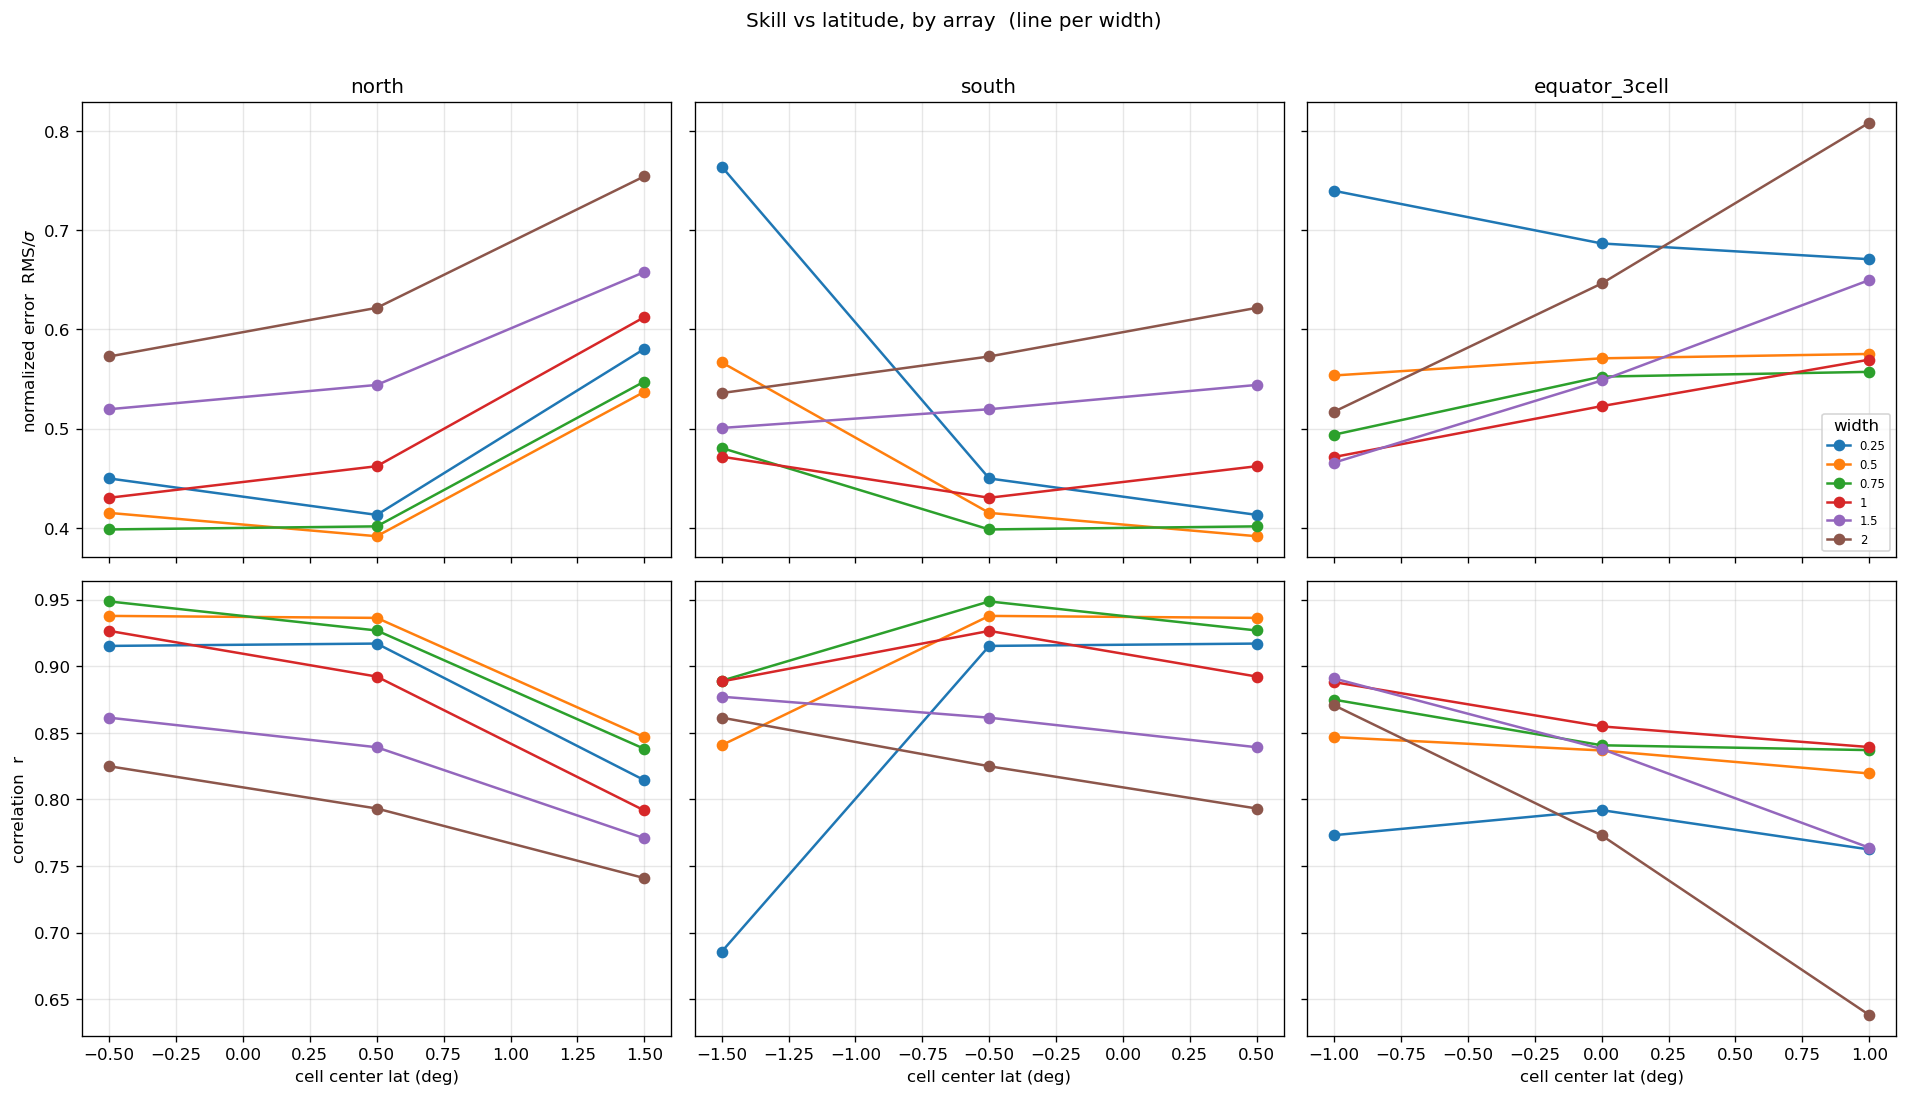

In [5]:
# Figure 3 - skill vs latitude for the multi-latitude arrays, one line per width.
lat_pats = ["north", "south", "equator_3cell"]      # metrics 'pattern' values
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex="col", sharey="row")
for j, pat in enumerate(lat_pats):
    d = m[m.pattern == pat]
    for w, dd in d.groupby("width"):
        dd = dd.sort_values("center_lat")
        axes[0, j].plot(dd.center_lat, dd.norm_rms, "o-", label=f"{w:g}")
        axes[1, j].plot(dd.center_lat, dd["corr"], "o-", label=f"{w:g}")
    axes[0, j].set_title(pat)
    axes[1, j].set_xlabel("cell center lat (deg)")
    for i in (0, 1):
        axes[i, j].grid(alpha=0.3)
axes[0, 0].set_ylabel(r"normalized error  RMS/$\sigma$")
axes[1, 0].set_ylabel("correlation  r")
axes[0, 2].legend(title="width", fontsize=7)
fig.suptitle("Skill vs latitude, by array  (line per width)", y=1.01)
fig.tight_layout()
fig.savefig(os.path.join(SUMDIR, "fig3_skill_vs_latitude.png"), dpi=150, bbox_inches="tight")
plt.show()

## Figure 4 - skill vs gliders-per-cell

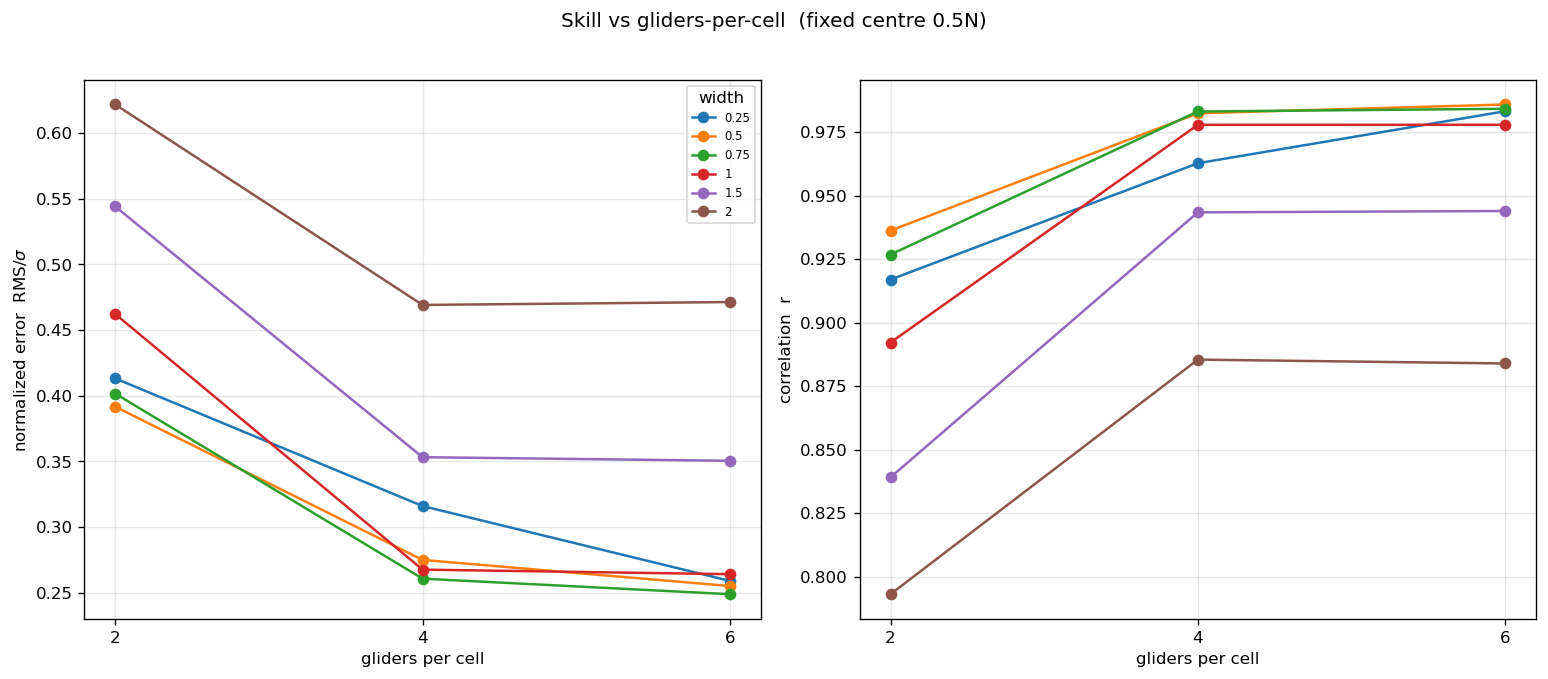

In [6]:
# Figure 4 - skill vs gliders-per-cell at fixed centre 0.5N, one line per width.
d = m[m.family == "density"]
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for w, dd in d.groupby("width"):
    dd = dd.sort_values("n_gliders_cell")
    axes[0].plot(dd.n_gliders_cell, dd.norm_rms, "o-", label=f"{w:g}")
    axes[1].plot(dd.n_gliders_cell, dd["corr"], "o-", label=f"{w:g}")
axes[0].set_ylabel(r"normalized error  RMS/$\sigma$")
axes[1].set_ylabel("correlation  r")
for ax in axes:
    ax.set_xlabel("gliders per cell"); ax.set_xticks([2, 4, 6]); ax.grid(alpha=0.3)
axes[0].legend(title="width", fontsize=7)
fig.suptitle("Skill vs gliders-per-cell  (fixed centre 0.5N)", y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(SUMDIR, "fig4_skill_vs_gliders.png"), dpi=150, bbox_inches="tight")
plt.show()

## Figure 5 - skill vs depth

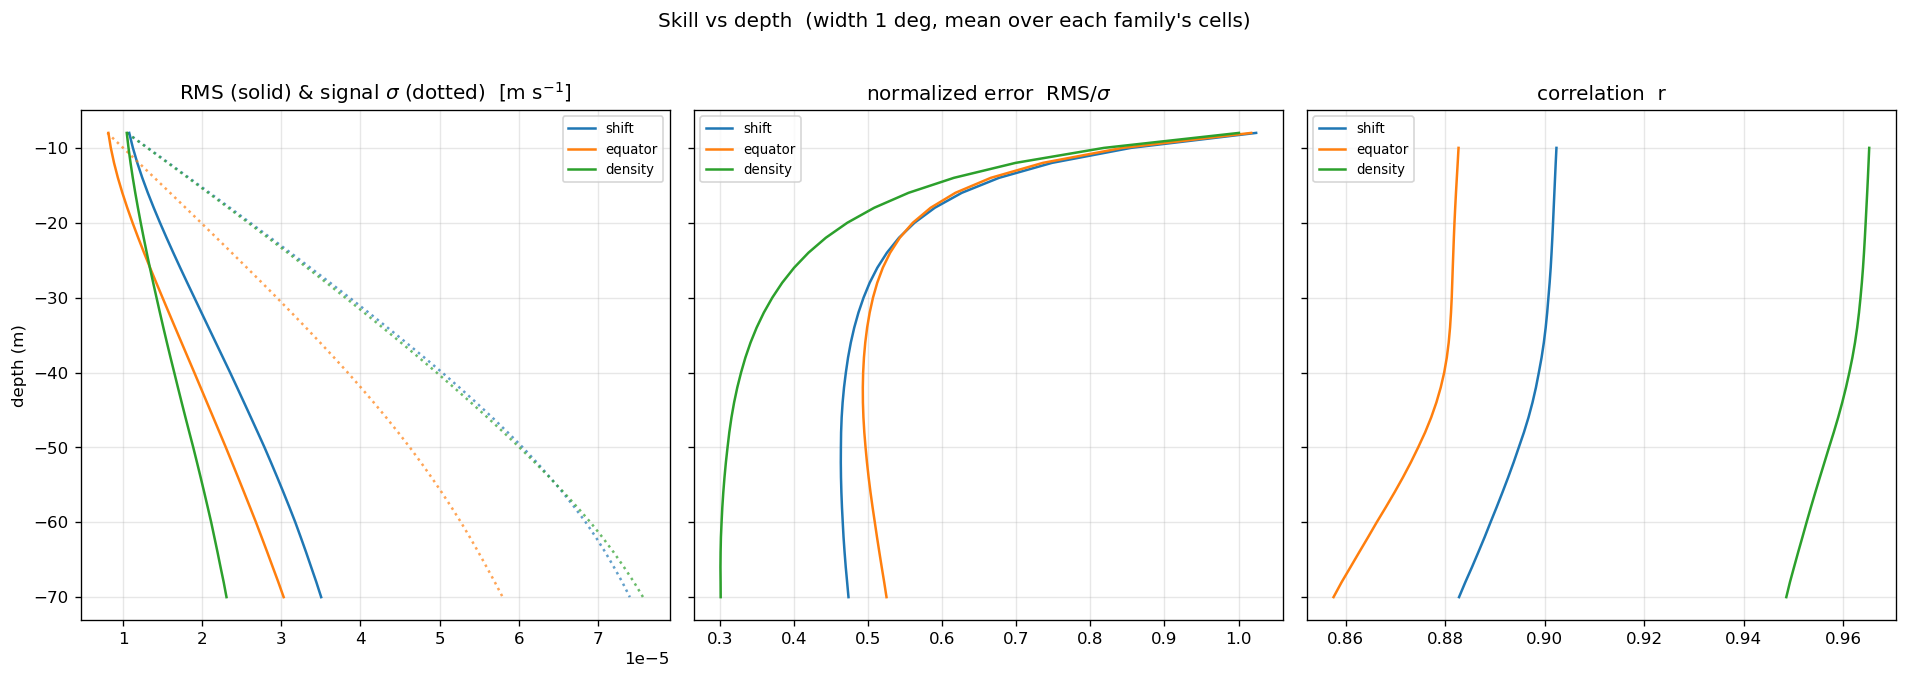

In [7]:
# Figure 5 - skill vs depth within the sampled 8-70 m range, at one width (DEPTH_WIDTH).
# Depth-resolved stats are averaged over each family's cells. Left panel overlays the
# signal std (dotted) so error can be read against the thing being estimated.
DEPTH_WIDTH = 1.0
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5), sharey=True)
for fam, c in FAM_COLORS.items():
    rows = m[(m.family == fam) & (np.isclose(m.width, DEPTH_WIDTH))]
    bds = [ot.w_skill_by_depth(ds.w_est, ds.w_model)
           for ds in (load_cell(r) for _, r in rows.iterrows())]
    B = xr.concat(bds, dim="cell").mean("cell")
    z = B.depth
    axes[0].plot(B.rms, z, color=c, label=fam)
    axes[0].plot(B.w_model_std, z, color=c, ls=":", alpha=0.7)
    axes[1].plot(B.norm_rms, z, color=c, label=fam)
    axes[2].plot(B["corr"], z, color=c, label=fam)
axes[0].set_title(r"RMS (solid) & signal $\sigma$ (dotted)  [m s$^{-1}$]")
axes[1].set_title(r"normalized error  RMS/$\sigma$")
axes[2].set_title("correlation  r")
axes[0].set_ylabel("depth (m)")
for ax in axes:
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
fig.suptitle(f"Skill vs depth  (width {DEPTH_WIDTH:g} deg, mean over each family's cells)", y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(SUMDIR, "fig5_skill_vs_depth.png"), dpi=150, bbox_inches="tight")
plt.show()